# Sinusoidal Encoding in PyTorch

In [1]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from models.deep_learning.architectures import MLP
from models.deep_learning.components.embeddings.visualization import plot_embeddingdims, plot_embedding
from models.deep_learning.components import FourierPositionalEncoding
device = torch.device("mps")

### Sinusoidal Positional Encoding

For a position $pos$ and embedding dimension $i$:

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d}}}\right)
$$

where:
- $pos$ is the position index
- $i$ is the dimension index
- $d$ is the total embedding dimension

In [2]:
fourier_posenc = FourierPositionalEncoding(embed_dim=24).to(device)
emb = fourier_posenc(spatial_dimensions=(50,))
emb.shape

torch.Size([50, 24])

## Embedding Visualization (per dimension)

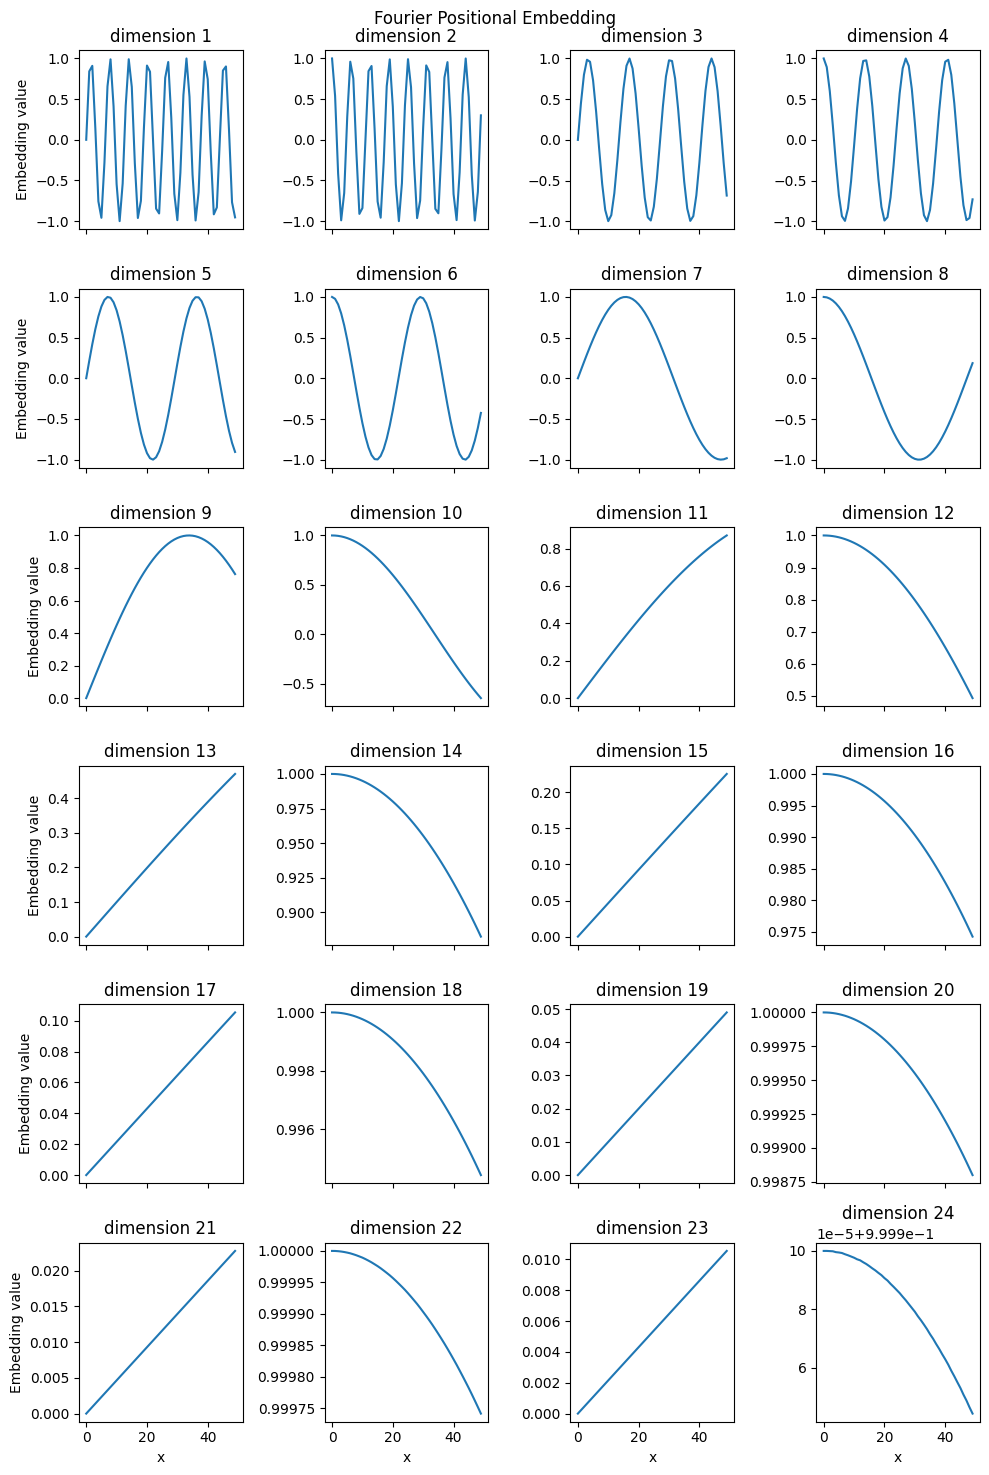

In [4]:
position = FourierPositionalEncoding.make_coords((50,), torch.device("cpu"))

plot_embeddingdims(position, emb.detach().cpu(), title="Fourier Positional Embedding")

## Embedding Visualization (heat map)

In the 1D case (sequence), this formulation is equivalent to the sinusoidal positional encoding used in the Transformer, as it employs the same frequency scaling.

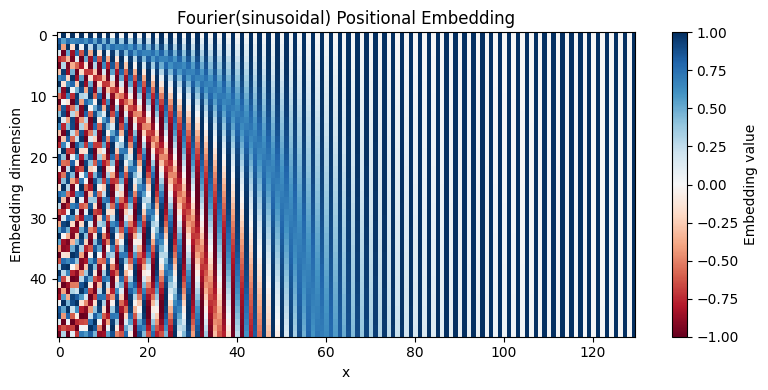

In [5]:
fourier_posenc = FourierPositionalEncoding(embed_dim=130).to(device)
emb = fourier_posenc(spatial_dimensions=(50,))

plot_embedding(emb.detach().cpu(), "Fourier(sinusoidal) Positional Embedding")

In [6]:
SM=emb@emb.T

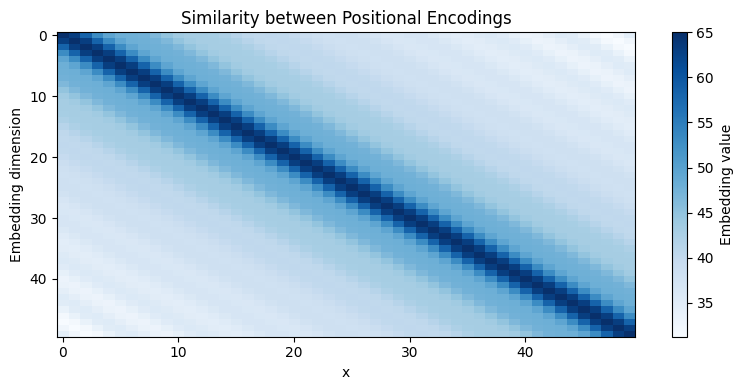

In [7]:
plot_embedding(SM.detach().cpu(), "Similarity between Positional Encodings",cmap="Blues", vmin=SM.min(), vmax=SM.max())

## Test

Lets learn a figure map (from spatial position to pixel colors)

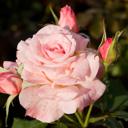

In [8]:
im = Image.open('rose_crop.jpeg').convert('RGB')
im_small = im.resize((128, 128))
im_small

## Learn without positional encoding

In [9]:
rosenet = MLP(input_dim=2,output_dim=3,hidden_dims=[256,128,64],activation_cls=nn.ReLU)    

In [10]:
rose_tensor = torch.as_tensor(np.array(im_small),dtype=torch.float32) / 255. - 0.5
xs = torch.linspace(-1, 1, im_small.size[1])
ys = torch.linspace(-1, 1, im_small.size[0])  

norm_position = torch.stack(
    torch.meshgrid(ys, xs, indexing="ij"),  
    dim=-1,
)
norm_position.shape

torch.Size([128, 128, 2])

## Training

In [11]:
rose_tensor = rose_tensor.to(device)
norm_position = norm_position.to(device)

net = rosenet.to(device)
optim = torch.optim.Adam(net.parameters(), lr=1e-3)

for it in range(5000):
    optim.zero_grad()
    loss = abs(net(norm_position)- rose_tensor).mean()
    loss.backward()
    optim.step()
    if it % 100 == 0:
        print(f"Iteration {it}, loss: {loss.item():.6f}")

Iteration 0, loss: 0.330755
Iteration 100, loss: 0.109981
Iteration 200, loss: 0.092854
Iteration 300, loss: 0.085759
Iteration 400, loss: 0.079697
Iteration 500, loss: 0.075097
Iteration 600, loss: 0.074238
Iteration 700, loss: 0.073437
Iteration 800, loss: 0.068556
Iteration 900, loss: 0.067702
Iteration 1000, loss: 0.066039
Iteration 1100, loss: 0.068026
Iteration 1200, loss: 0.064037
Iteration 1300, loss: 0.064933
Iteration 1400, loss: 0.061463
Iteration 1500, loss: 0.060977
Iteration 1600, loss: 0.061626
Iteration 1700, loss: 0.058949
Iteration 1800, loss: 0.061345
Iteration 1900, loss: 0.060139
Iteration 2000, loss: 0.057427
Iteration 2100, loss: 0.058920
Iteration 2200, loss: 0.056534
Iteration 2300, loss: 0.056690
Iteration 2400, loss: 0.057207
Iteration 2500, loss: 0.055443
Iteration 2600, loss: 0.055821
Iteration 2700, loss: 0.056393
Iteration 2800, loss: 0.054122
Iteration 2900, loss: 0.055276
Iteration 3000, loss: 0.054251
Iteration 3100, loss: 0.054267
Iteration 3200, loss

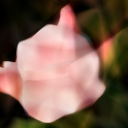

In [12]:
Image.fromarray(((net(norm_position)+0.5).clamp(0,1).cpu().detach().numpy()*255).astype(np.uint8))

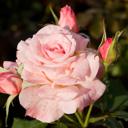

In [13]:
im_small

## Training with Sinusoidal positional encoding

In [14]:
emb_dim = 16
fourier_posenc = FourierPositionalEncoding(embed_dim=emb_dim, ndim=2).to(device)
rosenet = MLP(input_dim=emb_dim,output_dim=3,hidden_dims=[256,128,64],activation_cls=nn.ReLU).to(device)   
fourier_posenc(spatial_dimensions=im_small.size).shape

torch.Size([128, 128, 16])

In [ ]:
rose_tensor = rose_tensor.to(device)
optim = torch.optim.Adam(rosenet.parameters(), lr=1e-3)

for it in range(5000):
    optim.zero_grad()
    loss = abs(rosenet(fourier_posenc(im_small.size)) - rose_tensor).mean()
    loss.backward()
    optim.step()
    if it % 100 == 0:
        print(f"Iteration {it}, loss: {loss.item():.6f}")

Iteration 0, loss: 0.317364
Iteration 100, loss: 0.090177
Iteration 200, loss: 0.070266
Iteration 300, loss: 0.059456
Iteration 400, loss: 0.056795
Iteration 500, loss: 0.050855
Iteration 600, loss: 0.052270
Iteration 700, loss: 0.044604
Iteration 800, loss: 0.043448
Iteration 900, loss: 0.042040
Iteration 1000, loss: 0.039385
Iteration 1100, loss: 0.040248
Iteration 1200, loss: 0.037208
Iteration 1300, loss: 0.036695
Iteration 1400, loss: 0.035901
Iteration 1500, loss: 0.036193
Iteration 1600, loss: 0.035213
Iteration 1700, loss: 0.032587
Iteration 1800, loss: 0.034516
Iteration 1900, loss: 0.032088
Iteration 2000, loss: 0.031257
Iteration 2100, loss: 0.031443
Iteration 2200, loss: 0.032918
Iteration 2300, loss: 0.029738
Iteration 2400, loss: 0.032373
Iteration 2500, loss: 0.029306
Iteration 2600, loss: 0.031837
Iteration 2700, loss: 0.028224
Iteration 2800, loss: 0.026759
Iteration 2900, loss: 0.027712
Iteration 3000, loss: 0.026559
Iteration 3100, loss: 0.026972
Iteration 3200, loss

In [ ]:
img_gen = rosenet(fourier_posenc(im_small.size)).detach().cpu()
img_gen.shape

torch.Size([128, 128, 3])

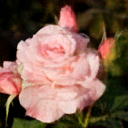

In [ ]:
Image.fromarray(((img_gen+0.5).clamp(0,1).cpu().detach().numpy()*255).astype(np.uint8))

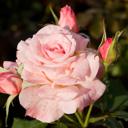

In [ ]:
im_small

## Generalization (bigger image)

In [ ]:
img_gen = rosenet(fourier_posenc(im_small.size, sampling_factor=8))
img_gen.shape

torch.Size([1024, 1024, 3])

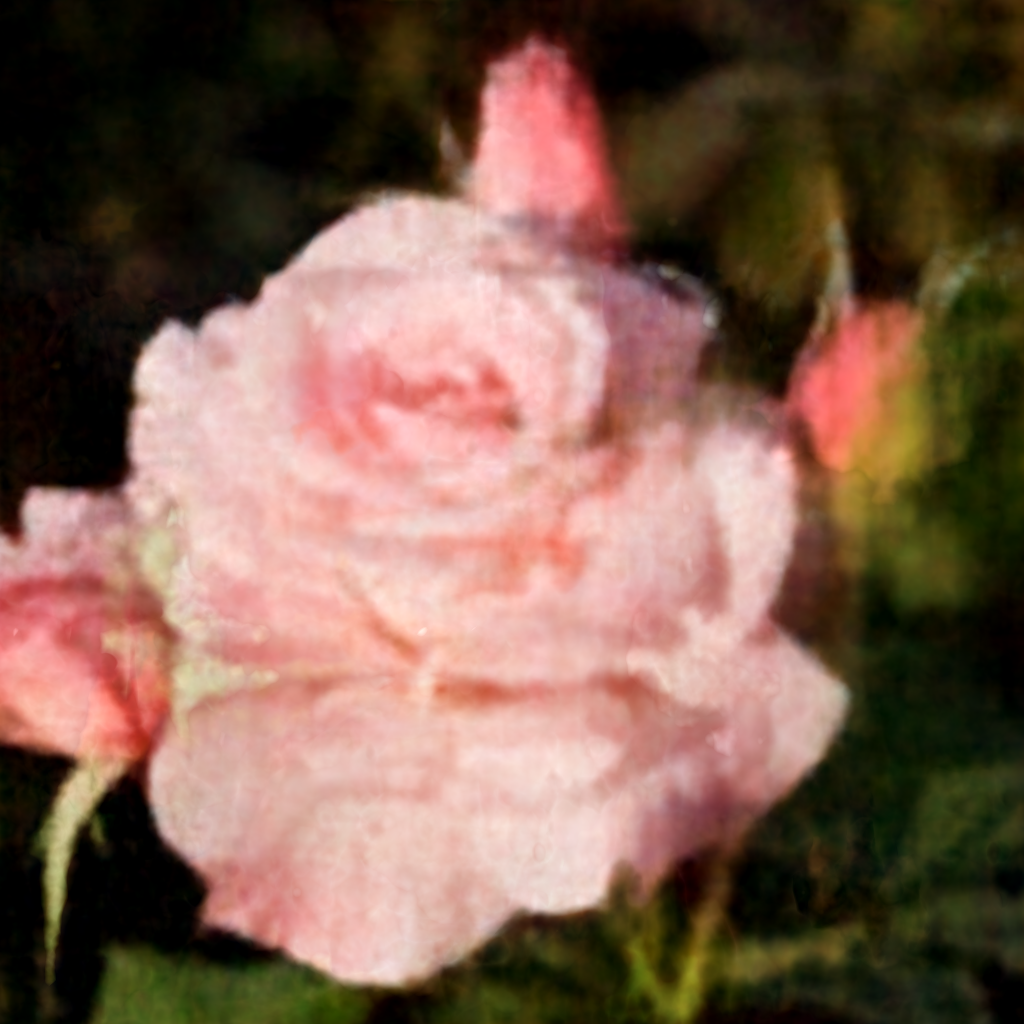

In [ ]:
Image.fromarray(((img_gen+0.5).clamp(0,1).cpu().detach().numpy()*255).astype(np.uint8))

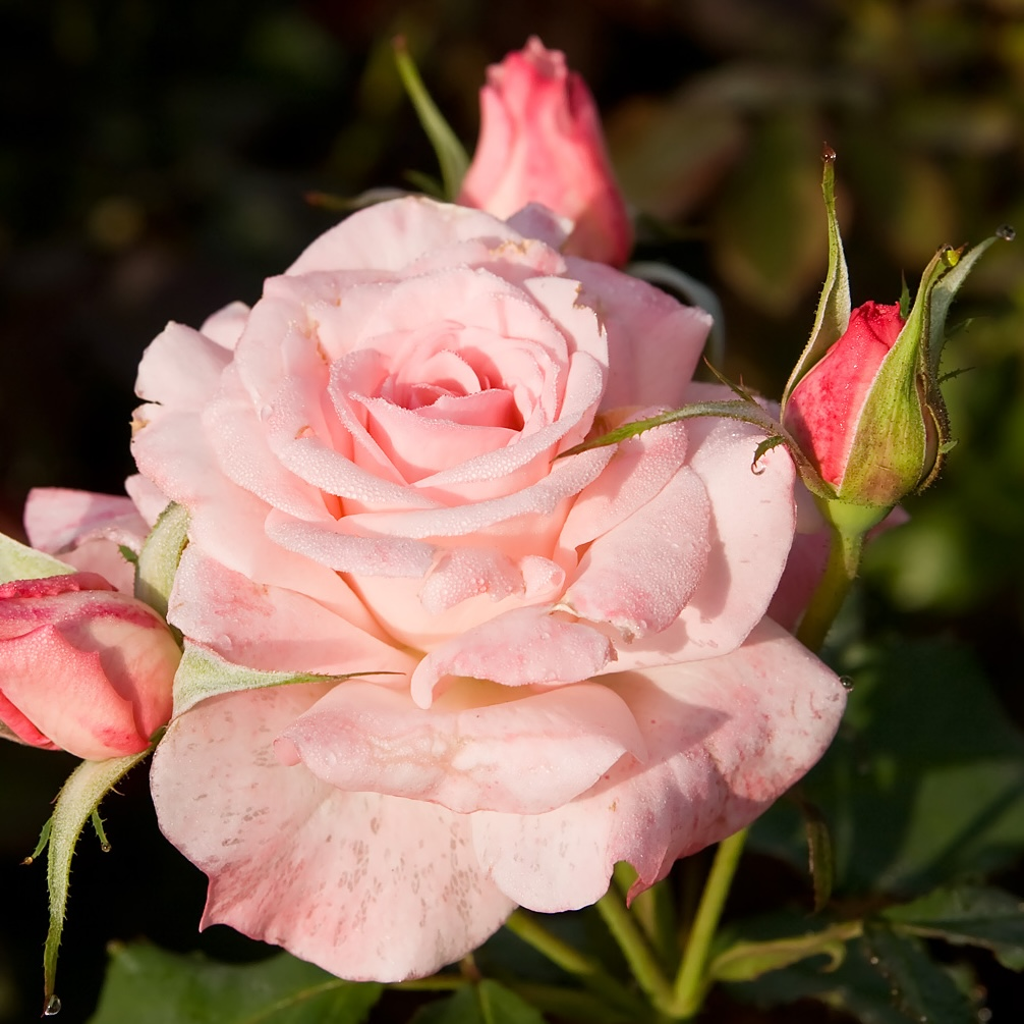

In [ ]:
im.resize((1024, 1024))

In [ ]:
enb_flat= fourier_posenc(im_small.size).flatten(end_dim=1)
enb_flat.shape

torch.Size([16384, 16])

In [ ]:
im_small.size

(128, 128)

## Flatten similarity

After flattening the spatial dimensions, long-range correlations become more visible: sinusoidal encodings capture local positional differences well, but their periodic nature introduces global ambiguities, causing distant positions to appear similar.

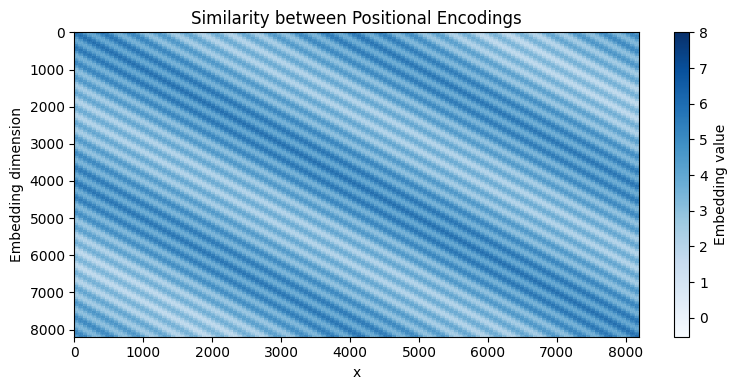

In [ ]:
SM = enb_flat @ enb_flat.T
sm=SM[::2,::2]
plot_embedding(sm.detach().cpu(), "Similarity between Positional Encodings",cmap="Blues", vmin=sm.min(), vmax=sm.max())